##EDA

##Step 1 - Import Libraries and Load Data

In this step I'm importing the libraries I'll need throughout the analysis and loading both datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

panel_df = pd.read_csv("/content/final_panel_dataset.csv")
ml_df = pd.read_csv("/content/final_ML_dataset.csv")

print("Panel Dataset Shape:", panel_df.shape)
print("ML Dataset Shape:", ml_df.shape)

Panel Dataset Shape: (8444, 10)
ML Dataset Shape: (361, 13)


##Step 2 - Basic Overview of the Datasets

Before jumping into analysis, I want to get a feel for what the data looks like, the structure, column types, and if there are any missing values.

In [ ]:
print("Panel Dataset Info")
print(panel_df.dtypes)
print("\nMissing Values in Panel Dataset:")
print(panel_df.isnull().sum())

print("\nML Dataset Info")
print(ml_df.dtypes)
print("\nMissing Values in ML Dataset:")
print(ml_df.isnull().sum())

Panel Dataset Info
SCHOOL_ID          int64
YEAR              object
COUNTY            object
SCHOOL_NAME       object
SCHOOL_TYPE       object
GRADE             object
FRL_PERCENT       object
FRL_COUNT         object
ENROLLED           int64
TOTAL_STUDENTS     int64
dtype: object

Missing Values in Panel Dataset:
SCHOOL_ID         0
YEAR              0
COUNTY            0
SCHOOL_NAME       0
SCHOOL_TYPE       0
GRADE             0
FRL_PERCENT       4
FRL_COUNT         4
ENROLLED          0
TOTAL_STUDENTS    0
dtype: int64

ML Dataset Info
SCHOOL_ID                int64
YEAR                    object
COUNTY                  object
SCHOOL_NAME             object
SCHOOL_TYPE             object
GRADE                   object
FRL_PERCENT             object
FRL_COUNT               object
ENROLLED                 int64
TOTAL_STUDENTS           int64
DISTRICT_ID              int64
DIST_KEY                 int64
CHRONIC_ABSENT_RATE    float64
dtype: object

Missing Values in ML Dataset:
SCHOO

##Step 3 - Summary Statistics

Here I'm looking at the basic statistics for both datasets to understand the range and distribution of the key variables.

In [ ]:
print("Panel Dataset Summary")
panel_df.describe()

Panel Dataset Summary


,SCHOOL_ID,ENROLLED,TOTAL_STUDENTS
count,8.444000e+03,8444.000000,8444.000000
mean,4.477275e+08,302.316556,302.322477
std,2.471584e+08,339.597224,339.597806
min,1.000300e+07,1.000000,1.000000
25%,2.800010e+08,102.000000,102.000000
50%,4.007040e+08,208.000000,208.000000
75%,6.605010e+08,382.000000,382.000000
max,9.307030e+08,2987.000000,2987.000000


In [ ]:
print("ML Dataset Summary")
ml_df.describe()

ML Dataset Summary


,SCHOOL_ID,ENROLLED,TOTAL_STUDENTS,DISTRICT_ID,DIST_KEY,CHRONIC_ABSENT_RATE
count,3.610000e+02,361.000000,361.000000,3.610000e+02,361.000000,361.000000
mean,5.039019e+07,207.324100,207.324100,4.161413e+07,41614.121884,0.149931
std,4.611185e+07,208.899212,208.899212,2.839309e+07,28393.097849,0.098255
min,1.000300e+07,25.000000,25.000000,1.000300e+07,10003.000000,0.035700
25%,1.012300e+07,77.000000,77.000000,1.012300e+07,10123.000000,0.080100
50%,4.000100e+07,122.000000,122.000000,3.050000e+07,30500.000000,0.117800
75%,7.000601e+07,286.000000,286.000000,7.000600e+07,70006.000000,0.198200
max,2.200110e+08,1189.000000,1189.000000,9.001001e+07,90010.000000,0.483100


##Step 4 - Distribution of FRL Percent

I want to see how poverty levels are distributed across all Nebraska schools over the 7 years.


In [ ]:
print(panel_df["FRL_PERCENT"].head())

0     0.315
1    0.3289
2    0.5435
3    0.6294
4    0.7436
Name: FRL_PERCENT, dtype: object


In [ ]:
panel_df["FRL_PERCENT"] = pd.to_numeric(panel_df["FRL_PERCENT"], errors="coerce")
ml_df["CHRONIC_ABSENT_RATE"] = pd.to_numeric(ml_df["CHRONIC_ABSENT_RATE"], errors="coerce")

print(panel_df["FRL_PERCENT"].dtype)
print(panel_df["FRL_PERCENT"].head())

float64
0    0.3150
1    0.3289
2    0.5435
3    0.6294
4    0.7436
Name: FRL_PERCENT, dtype: float64


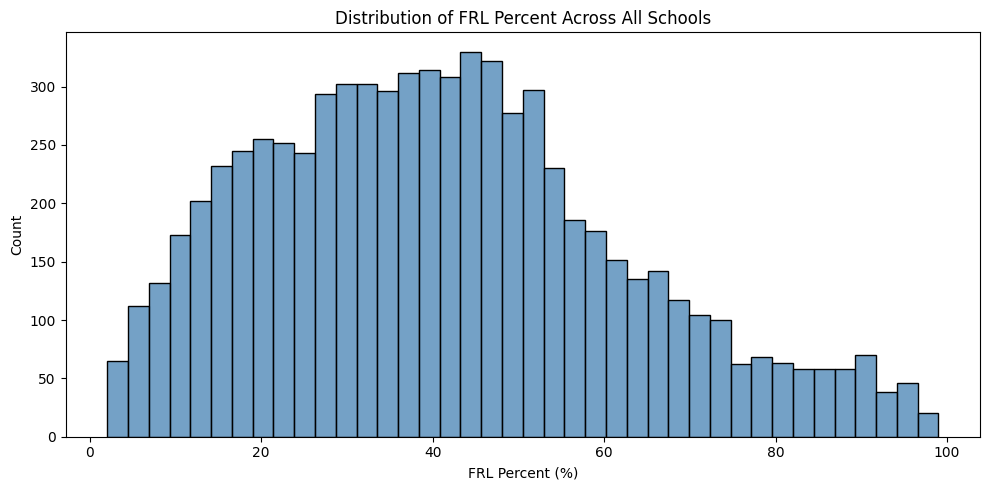

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(panel_df["FRL_PERCENT"] * 100, bins=40, color="steelblue", edgecolor="black")
plt.title("Distribution of FRL Percent Across All Schools")
plt.xlabel("FRL Percent (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Step 5 - Distribution of Chronic Absenteeism Rate

Now I want to see how the target variable is distributed across the schools we have absence data for.

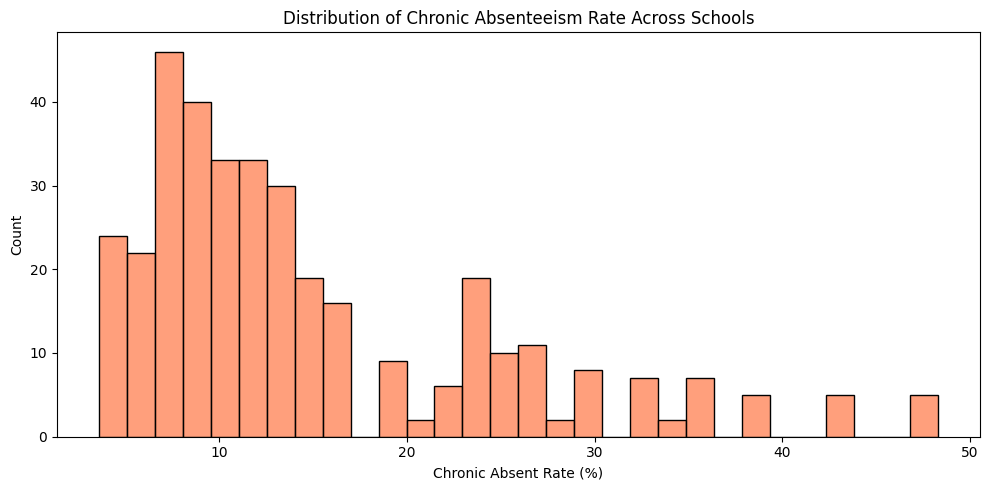

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(ml_df["CHRONIC_ABSENT_RATE"] * 100, bins=30, color="coral", edgecolor="black")
plt.title("Distribution of Chronic Absenteeism Rate Across Schools")
plt.xlabel("Chronic Absent Rate (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Step 6 - Average FRL Percent Over 7 Years

I want to see how poverty levels have changed across Nebraska schools year by year.


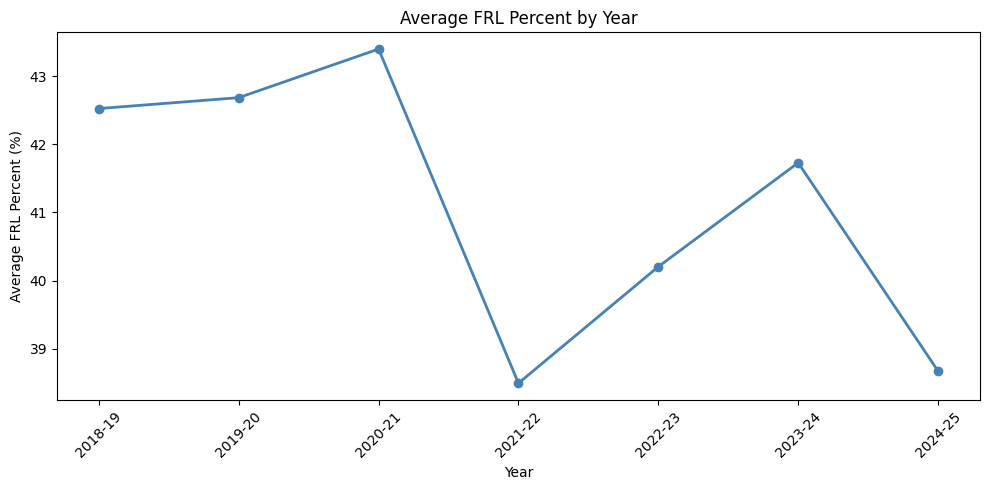

In [ ]:
frl_trend = panel_df.groupby("YEAR")["FRL_PERCENT"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(frl_trend.index, frl_trend.values, marker="o", color="steelblue", linewidth=2)
plt.title("Average FRL Percent by Year")
plt.xlabel("Year")
plt.ylabel("Average FRL Percent (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Step 7 - Average Chronic Absenteeism Rate Over 7 Years

Now I want to see how absenteeism changed year by year — this is where the COVID effect should be very visible.


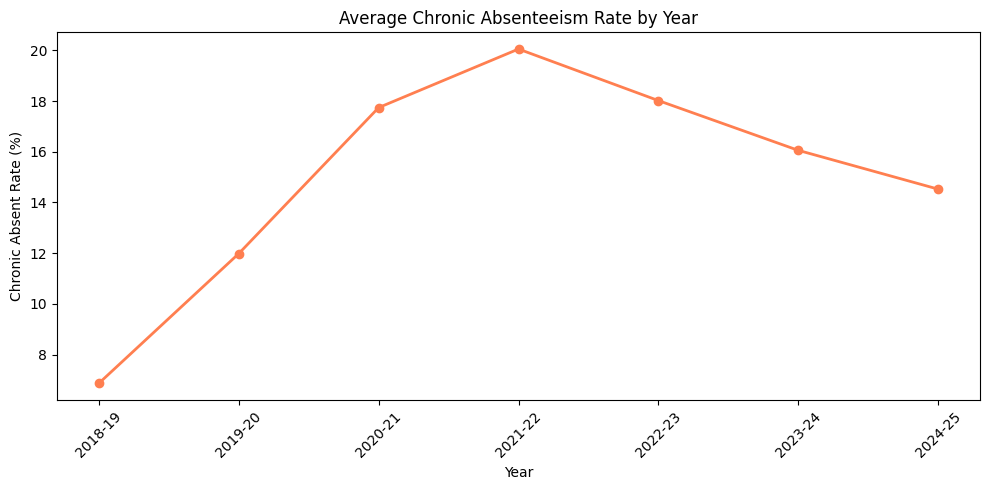

In [ ]:
absent_trend = ml_df.groupby("YEAR")["CHRONIC_ABSENT_RATE"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(absent_trend.index, absent_trend.values, marker="o", color="coral", linewidth=2)
plt.title("Average Chronic Absenteeism Rate by Year")
plt.xlabel("Year")
plt.ylabel("Chronic Absent Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Step 8 - Absenteeism by School Type

I want to see which type of school has the highest chronic absenteeism rate.

/tmp/ipykernel_28815/7371596.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ml_df, x="SCHOOL_TYPE", y="CHRONIC_ABSENT_RATE", palette="Set2")


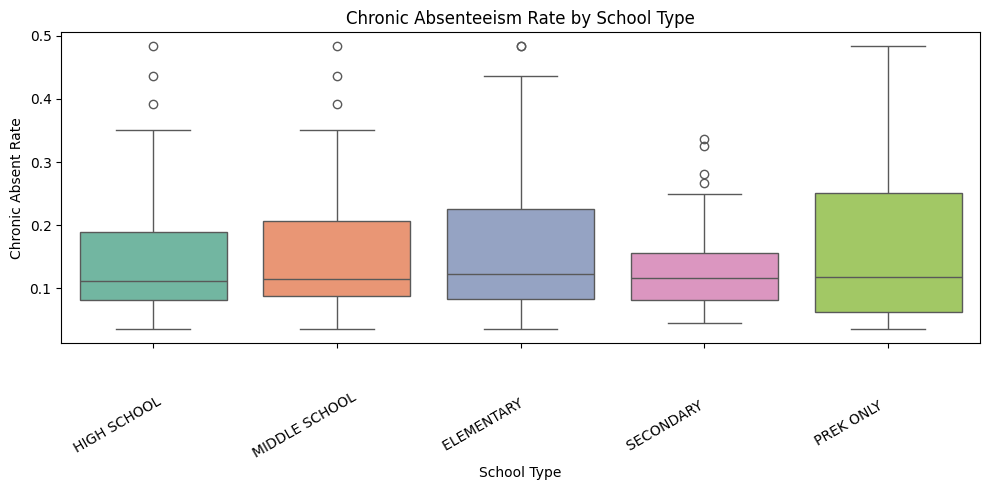

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=ml_df, x="SCHOOL_TYPE", y="CHRONIC_ABSENT_RATE", palette="Set2")
plt.title("Chronic Absenteeism Rate by School Type")
plt.xlabel("School Type")
plt.ylabel("Chronic Absent Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##Step 9 - Top 15 Counties by Average FRL Percent

I want to see which counties in Nebraska have the highest poverty levels on average across all 7 years.

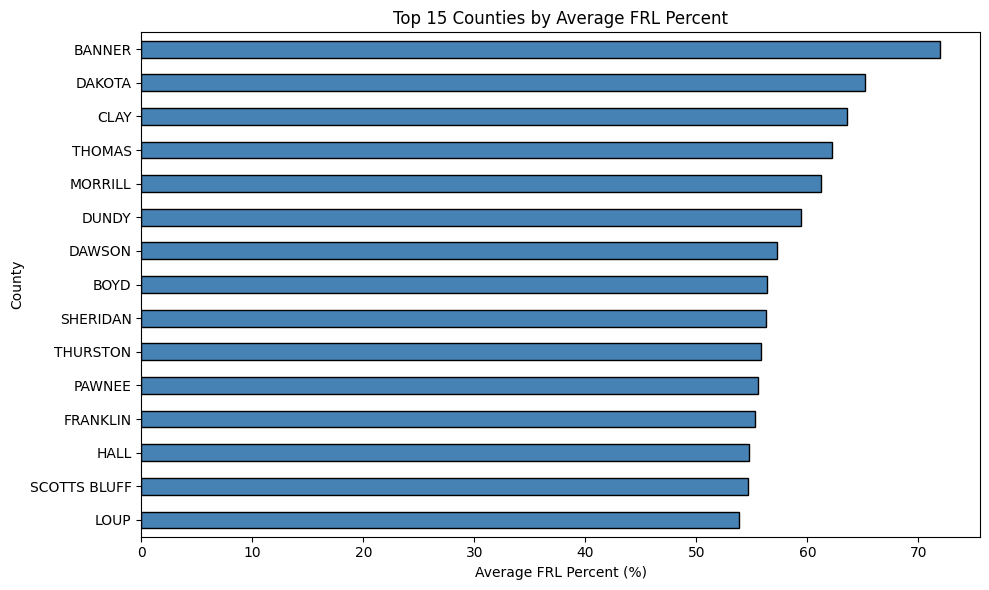

In [ ]:
top_counties_frl = panel_df.groupby("COUNTY")["FRL_PERCENT"].mean() * 100
top_counties_frl = top_counties_frl.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_counties_frl.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 15 Counties by Average FRL Percent")
plt.xlabel("Average FRL Percent (%)")
plt.ylabel("County")
plt.tight_layout()
plt.show()

##Step 10 - Top 15 Counties by Chronic Absenteeism Rate

Now I want to see which counties have the highest absenteeism to compare with the poverty chart.

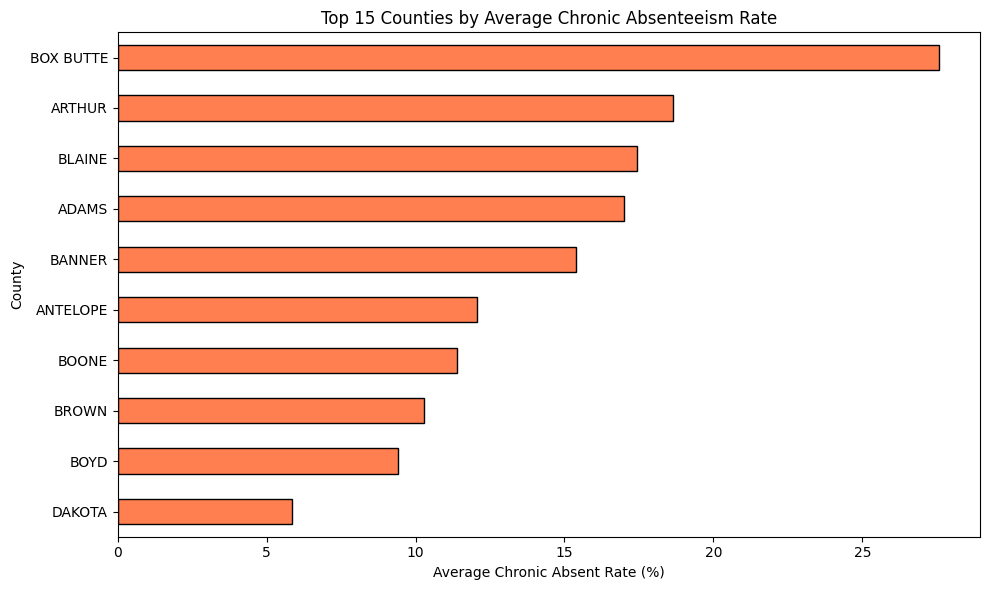

In [ ]:
top_counties_absent = ml_df.groupby("COUNTY")["CHRONIC_ABSENT_RATE"].mean() * 100
top_counties_absent = top_counties_absent.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_counties_absent.sort_values().plot(kind="barh", color="coral", edgecolor="black")
plt.title("Top 15 Counties by Average Chronic Absenteeism Rate")
plt.xlabel("Average Chronic Absent Rate (%)")
plt.ylabel("County")
plt.tight_layout()
plt.show()

##Step 11 - FRL Percent vs Chronic Absenteeism Rate

This is the most important chart — showing the direct relationship between poverty and absenteeism.

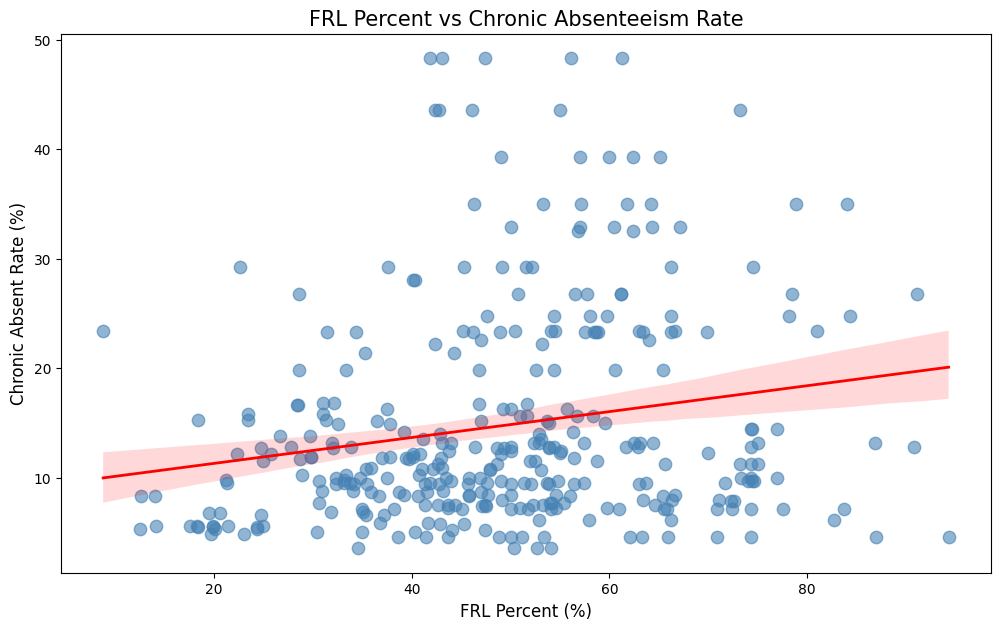

In [ ]:
ml_df["FRL_PERCENT"] = pd.to_numeric(ml_df["FRL_PERCENT"], errors="coerce")
ml_df["CHRONIC_ABSENT_RATE"] = pd.to_numeric(ml_df["CHRONIC_ABSENT_RATE"], errors="coerce")

plt.figure(figsize=(12, 7))
sns.regplot(x=ml_df["FRL_PERCENT"] * 100,
            y=ml_df["CHRONIC_ABSENT_RATE"] * 100,
            scatter_kws={"alpha": 0.6, "s": 80, "color": "steelblue"},
            line_kws={"color": "red", "linewidth": 2})
plt.title("FRL Percent vs Chronic Absenteeism Rate", fontsize=15)
plt.xlabel("FRL Percent (%)", fontsize=12)
plt.ylabel("Chronic Absent Rate (%)", fontsize=12)
plt.show()

##Step 12 - Correlation Heatmap

I want to see how all numeric variables relate to each other.

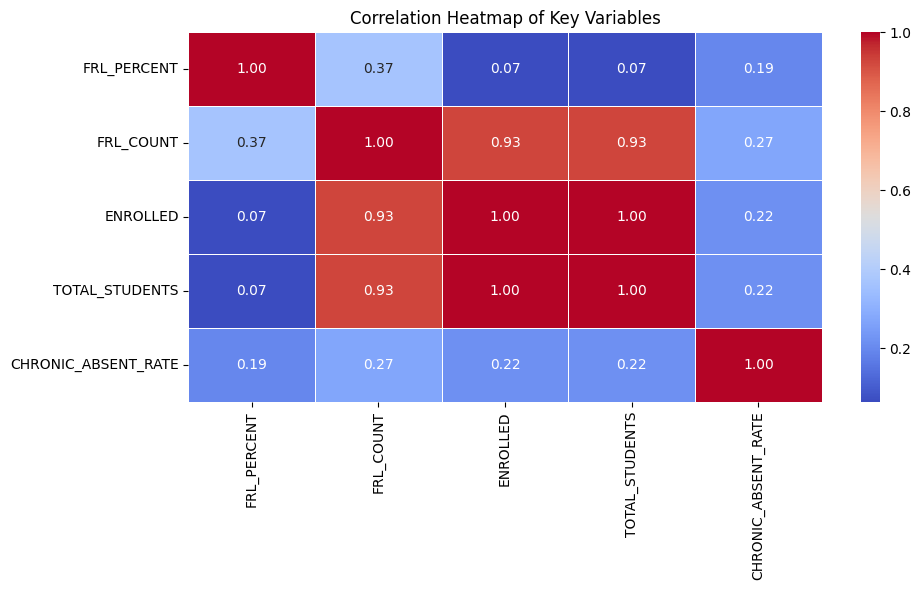

In [ ]:
for col in ["FRL_PERCENT", "FRL_COUNT", "ENROLLED", "TOTAL_STUDENTS", "CHRONIC_ABSENT_RATE"]:
    ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

numeric_cols = ml_df[["FRL_PERCENT", "FRL_COUNT", "ENROLLED", "TOTAL_STUDENTS", "CHRONIC_ABSENT_RATE"]]

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()

##Step 13 - Absenteeism Distribution by Year

This will show how absenteeism spread changed across all 7 years including the COVID spike.

/tmp/ipykernel_28815/2393936801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ml_df, x="YEAR", y="CHRONIC_ABSENT_RATE", palette="Set3")


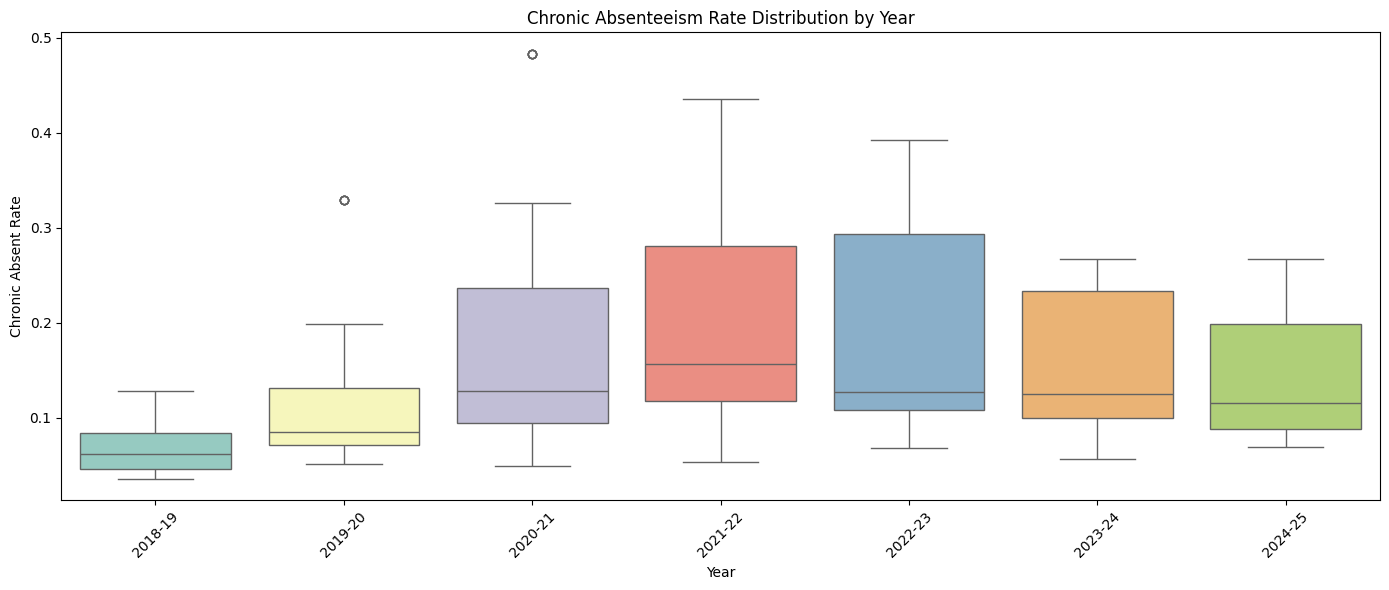

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=ml_df, x="YEAR", y="CHRONIC_ABSENT_RATE", palette="Set3")
plt.title("Chronic Absenteeism Rate Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Chronic Absent Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()